<a href="https://colab.research.google.com/github/Thaer-F-Ali/Logistitc_Regression_Implimitation/blob/main/logistic_regression_implimintaion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Logistic Regression

Logistic Regression is a supervised machine learning algorithm used for binary classification tasks. Below is a Python implementation using the scikit-learn library.

Steps to Implement Logistic Regression

1. Import Required Libraries

In [1]:
# 1. Laoding libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

2. Load and Prepare the Dataset

For demonstration, we'll use the diabetes dataset from sklearn.

In [2]:
# 2. Loading dataset and prepare dataset
from sklearn.datasets import load_diabetes
# Load dataset
data = load_diabetes()
X, y = data.data, data.target
# Convert target to binary (1 for diabetes, 0 for no diabetes)
y_binary = (y > np.median(y)).astype(int)

3. Split the Dataset

Split the data into training and testing sets.

In [3]:
# 3. Spliting data
X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size=0.3, random_state=42)

4. Feature Scaling

Standardize features to improve model performance.

In [4]:
# 4. Scalling data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

5. Train the Logistic Regression Model

Fit the logistic regression model on the training data.

In [5]:
# 5. Create logistic model and train it
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

6. Evaluate the Model

Evaluate the model's performance using accuracy and other metrics.

In [6]:
#6  Predict on test data
y_pred = model.predict(X_test)

# Accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Confusion Matrix and Classification Report
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 77.44%
Confusion Matrix:
 [[56 16]
 [14 47]]

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.78      0.79        72
           1       0.75      0.77      0.76        61

    accuracy                           0.77       133
   macro avg       0.77      0.77      0.77       133
weighted avg       0.78      0.77      0.77       133



In [7]:
# 7. printing the resuls (this source for comparing the results with program in the Applied Machine Learning with Python book, page 62)

print('Prediction:', y_pred[1], y_pred[9], y_pred[25])
print('Raw Model Output X_test: ',
      (model.coef_@ X_test[1]+model.intercept_),
      (model.coef_@X_test[9]+model.intercept_),
      (model.coef_@X_test[25] + model.intercept_))


Prediction: 1 0 1
Raw Model Output X_test:  [1.47532634] [-1.67518769] [0.52654523]


# 2nd Logistic Regersion

This model is from the Applied Machine Learning with Python book-page 62

In [8]:
# 1. Preparing data
X = data.data
y = data.target
print(data.feature_names)
print(data.DESCR)


['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, bloo

In [9]:
# 2. Spliting data
X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size= 0.3, random_state= 42)

In [10]:
# 3. Craeting the model and train it
lr = LogisticRegression()
lr.fit(X_train, y_train)


LogisticRegression()

In [11]:
# 3. Testting and evaluating the model
y_pred = lr.predict(X_test)

In [12]:
# 4. Examining the results
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Confusion Matrix and Classification Report
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 80.45%
Confusion Matrix:
 [[56 16]
 [10 51]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.78      0.81        72
           1       0.76      0.84      0.80        61

    accuracy                           0.80       133
   macro avg       0.80      0.81      0.80       133
weighted avg       0.81      0.80      0.80       133



### Comparing Coefficients of Scaled vs. Unscaled Models

In [13]:
# 5. Printing the coefficients
print('Prediction:', lr.predict(X_test)[1], lr.predict(X_test)[9], lr.predict(X_test)[25])
print('Raw Model Output X_test: ',
      (lr.coef_@ X_test[1] + lr.intercept_),
      (lr.coef_@ X_test[9] + lr.intercept_),
      (lr.coef_@ X_test[25]+ lr.intercept_))


Prediction: 1 0 1
Raw Model Output X_test:  [0.1352537] [-0.09852356] [0.17023003]


In [14]:
# 6. Comparing cofficients of the scaled and unscaled models
print("Scaled Model (model):")
print("  Coefficients:", model.coef_)
print("  Intercept:", model.intercept_)

print("\nUnscaled Model (lr):")
print("  Coefficients:", lr.coef_)
print("  Intercept:", lr.intercept_)

Scaled Model (model):
  Coefficients: [[ 0.10500243 -0.58724547  0.67459032  0.61835658 -0.32022822 -0.08939562
  -0.52441695  0.09787805  0.62173009 -0.04851767]]
  Intercept: [0.14722282]

Unscaled Model (lr):
  Coefficients: [[ 0.57359398 -0.65002523  2.35591272  1.85001384  0.18766705  0.06003926
  -1.59215119  1.32216707  1.94320318  1.15471231]]
  Intercept: [0.05378309]


# 3rd Logistic Regression with data analysis in real example

*   This example is from the Kegale platform with name Diabetes Analysis
*   The dataset is a collection from  African-American patients were included


---





In [15]:
#import important libraries
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import ConnectionPatch
import seaborn as sns
from scipy.stats import norm
import statistics
import plotly.graph_objects as go
import plotly.express as px
from plotly.offline import init_notebook_mode
init_notebook_mode(connected=True)

In [17]:
# 1. Importing dataset
# Please upload 'diabetes.csv' to your Colab session, or provide the correct path.
diab_data= pd.read_csv('/content/sample_data/germany_diabetes.csv')
diab_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,2,138,62,35,0,33.6,0.127,47,0
1,0,84,82,31,125,38.2,0.233,23,0
2,0,145,0,0,0,44.2,0.630,31,0
3,0,135,68,42,250,42.3,0.365,24,0
4,1,139,62,41,480,40.7,0.536,21,0


In [18]:
# Rename the boood_glucose_level to glyhd
diab_data = diab_data.rename(columns={'Outcome': 'glyhb'})
diab_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,glyhb
0,2,138,62,35,0,33.6,0.127,47,0
1,0,84,82,31,125,38.2,0.233,23,0
2,0,145,0,0,0,44.2,0.630,31,0
3,0,135,68,42,250,42.3,0.365,24,0
4,1,139,62,41,480,40.7,0.536,21,0


In [19]:
# Exploring data in the dataset
diab_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               2000 non-null   int64  
 1   Glucose                   2000 non-null   int64  
 2   BloodPressure             2000 non-null   int64  
 3   SkinThickness             2000 non-null   int64  
 4   Insulin                   2000 non-null   int64  
 5   BMI                       2000 non-null   float64
 6   DiabetesPedigreeFunction  2000 non-null   float64
 7   Age                       2000 non-null   int64  
 8   glyhb                     2000 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 140.8 KB


### Building LR model

Descriptive statistics for 'diabetes' column:


,DiabetesPedigreeFunction
count,2000.000000
mean,0.470930
std,0.323553
min,0.078000
25%,0.244000
50%,0.376000
75%,0.624000
max,2.420000


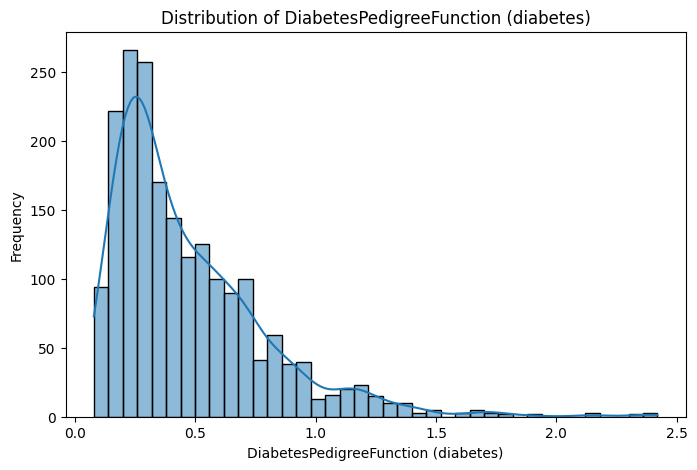

In [20]:
# 2.Understanding the 'diabetes' column
# Display descriptive statistics for 'diabetes'
print("Descriptive statistics for 'diabetes' column:")
display(diab_data['DiabetesPedigreeFunction'].describe())

# Visualize the distribution of 'glyhd'
plt.figure(figsize=(8, 5))
sns.histplot(diab_data['DiabetesPedigreeFunction'], kde=True)
plt.title('Distribution of DiabetesPedigreeFunction (diabetes)')
plt.xlabel('DiabetesPedigreeFunction (diabetes)')
plt.ylabel('Frequency')
plt.show()

In [ ]:
diab_data

In [21]:
# 3 Exploring nan in the data
print(diab_data.info())
diab_data.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               2000 non-null   int64  
 1   Glucose                   2000 non-null   int64  
 2   BloodPressure             2000 non-null   int64  
 3   SkinThickness             2000 non-null   int64  
 4   Insulin                   2000 non-null   int64  
 5   BMI                       2000 non-null   float64
 6   DiabetesPedigreeFunction  2000 non-null   float64
 7   Age                       2000 non-null   int64  
 8   glyhb                     2000 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 140.8 KB
None


,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
glyhb,0


In [22]:
# 4 Cleaning data
# Droping rows where 'glyhb' has missing values
diab_data = diab_data.dropna(subset=['glyhb'], how='any')

In [23]:
# 5. Cheking nan in the data
print(diab_data.info())
diab_data.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               2000 non-null   int64  
 1   Glucose                   2000 non-null   int64  
 2   BloodPressure             2000 non-null   int64  
 3   SkinThickness             2000 non-null   int64  
 4   Insulin                   2000 non-null   int64  
 5   BMI                       2000 non-null   float64
 6   DiabetesPedigreeFunction  2000 non-null   float64
 7   Age                       2000 non-null   int64  
 8   glyhb                     2000 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 140.8 KB
None


,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
glyhb,0


In [ ]:
# 6. Converting string data to number (Location, Gender, and Fram) for finding the correlattion between them
gender_map = {
    'Female': 0,
    'Male': 1
}
diab_data['gender'] = diab_data['gender'].map(gender_map)

'''location_map = {
    'Urban': 0,
    'Rural': 1
}
diab_data['location'] = diab_data['location'].map(location_map)

fram_map = {
    'No': 0,
    'Yes': 1
}
diab_data['frame'] = diab_data['frame'].map(fram_map)'''

In [ ]:
# Deleting geneder column
diab_data = diab_data.drop('gender', axis=1)
diab_data = diab_data.drop(columns=['smoking_history'])


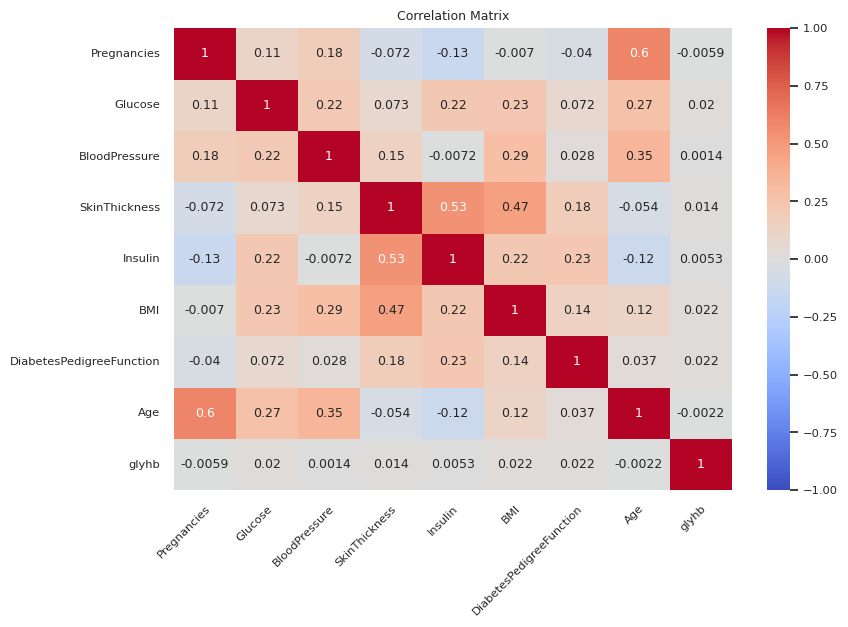

In [25]:
# 7. Showing the unnacessory columns ('smoking_history') to show clear corelationship

corr = diab_data.corr('spearman')
plt.figure(figsize=(9,6))
sns.set(font_scale=0.75)
ax = sns.heatmap(corr, vmin=-1, center=0, vmax=1, annot=True, cmap='coolwarm')
# Rotate x-axis labels (column names)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
# Rotate y-axis labels (column names)
plt.setp(ax.get_yticklabels(), rotation=0)
plt.title('Correlation Matrix')
plt.show()

In [ ]:
# 8. Deleting unusfel columns that show low correlation with glyb label
diab_data_corr = diab_data.drop(['id','location', 'gender','frame'], axis =1).corr('spearman')
for col in diab_data_corr.columns:
   if (diab_data_corr['glyhb'].corr(diab_data_corr[col])<=0):
    diab_data_corr = diab_data_corr.drop(col, axis=1)

In [26]:
# 8. This step is another way to drop columns
# Dropping uncorelated columns to the glyhb column
diab_data_corr = diab_data.copy() # Make a copy to avoid modifying the original DataFrame
x = 0
for col in diab_data_corr.columns:
   if col == 'glyhb': # Skip the target column itself
       print(f"Skipping target column: '{col}'")
       continue

   # Calculate correlation, handling potential NaN values if a column is all NaNs after dropna()
   if diab_data_corr[col].isnull().all(): # Check if column is entirely NaN
       correlation = 0 # Or handle as appropriate, e.g., drop it always
   else:
       correlation = diab_data_corr['glyhb'].corr(diab_data_corr[col])

   if (correlation <= 0.0):
    diab_data_corr = diab_data_corr.drop(col, axis=1)
    x = x+1
    print(f"True: Column '{col}' dropped due to correlation <= 0 (Correlation: {correlation:.2f})")
   else:
    print(f"False: Column '{col}' kept (Correlation: {correlation:.2f})")
print(f"Total columns dropped: {x}")


True: Column 'Pregnancies' dropped due to correlation <= 0 (Correlation: -0.01)
False: Column 'Glucose' kept (Correlation: 0.02)
True: Column 'BloodPressure' dropped due to correlation <= 0 (Correlation: -0.00)
False: Column 'SkinThickness' kept (Correlation: 0.02)
False: Column 'Insulin' kept (Correlation: 0.02)
False: Column 'BMI' kept (Correlation: 0.03)
False: Column 'DiabetesPedigreeFunction' kept (Correlation: 0.01)
True: Column 'Age' dropped due to correlation <= 0 (Correlation: -0.01)
Skipping target column: 'glyhb'
Total columns dropped: 3


In [27]:
# 8.1 Dropping all zero values from columns except glyhb
x = 0
for col in diab_data.columns:
   if col == 'glyhb': # Skip the target column itself
       print(f"Skipping target column: '{col}'")
       continue
       # Validate column existence
   if col in diab_data.columns:
        # Keep only rows where the column is NOT zero
        diab_data = diab_data[diab_data[col] != 0].reset_index(drop=True)
   else:
        raise ValueError(f"Column '{col}' does not exist in DataFrame.")

Skipping target column: 'glyhb'


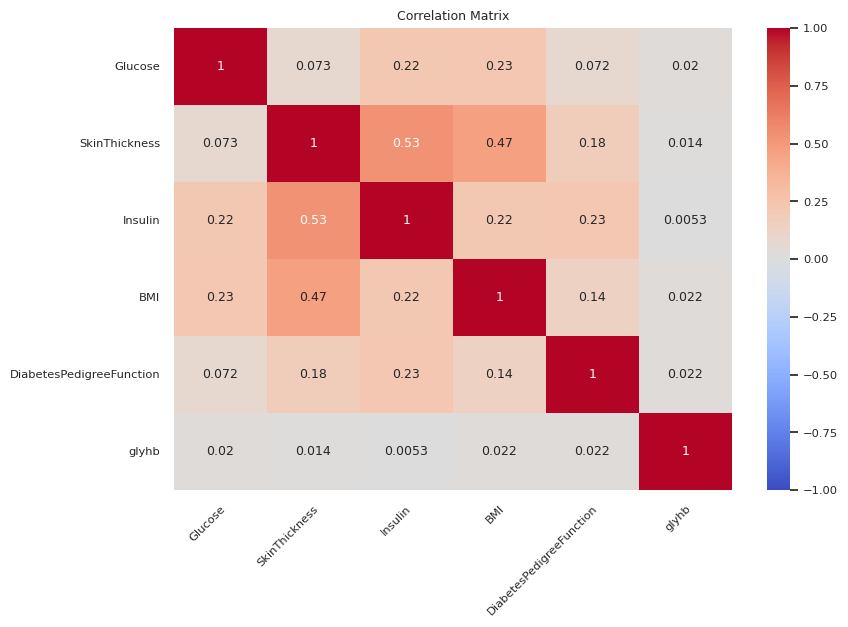

In [28]:
# 9. Exploring the correlation map with glyb for double check
corr = diab_data_corr.corr('spearman')
plt.figure(figsize=(9,6))
sns.set(font_scale=0.75)
ax = sns.heatmap(corr, vmin=-1, center=0, vmax=1, annot=True, cmap='coolwarm')
# Rotate x-axis labels (column names)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
# Rotate y-axis labels (column names)
plt.setp(ax.get_yticklabels(), rotation=0)
plt.title('Correlation Matrix')
plt.show()

In [51]:
# 10. Building data for the model

# First, ensure consistency by dropping rows with any NaN values from the relevant columns
# This step ensures X and y will have the same number of samples.
diab_data_cleaned = diab_data.dropna(how='any')

X = diab_data_cleaned.drop('glyhb', axis=1)
y = diab_data_cleaned['glyhb']

# Convert target to binary (1 for diabetes, 0 for no diabetes)
# Using a common clinical threshold for HbA1c: >= 6.5% for diabetes
#y_binary = (y >= 6.5).astype(int)
y_binary = (y > np.median(y)).astype(int)

# Spliting data
X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size= 0.3, random_state= 42)

# Normalizing data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

count    2000.000000
mean        0.342000
std         0.474498
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         1.000000
Name: glyhb, dtype: float64


<Axes: xlabel='glyhb', ylabel='Count'>

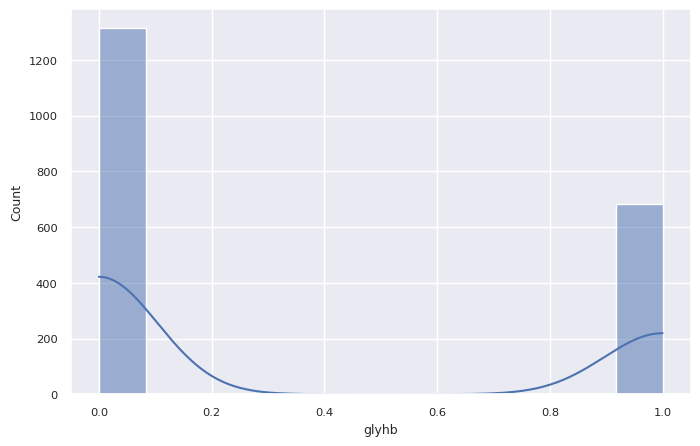

In [52]:
# 11. Exploring the glyhb column
glyb = diab_data_corr['glyhb']
print(glyb.describe())
plt.figure(figsize=(8, 5))
sns.histplot(glyb.dropna(), kde=True)

In [53]:
# 12. Building the Logistic Regression model
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [54]:
# 13. Predict on test data
y_pred = model.predict(X_test)

# Accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Confusion Matrix and Classification Report
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 70.72%
Confusion Matrix:
 [[186   3]
 [ 74   0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.98      0.83       189
           1       0.00      0.00      0.00        74

    accuracy                           0.71       263
   macro avg       0.36      0.49      0.41       263
weighted avg       0.51      0.71      0.60       263



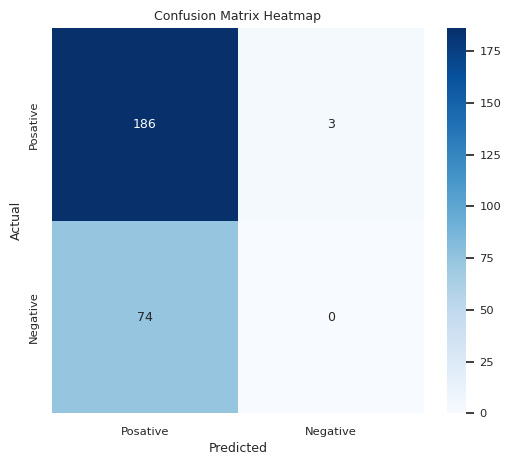

In [55]:
# 14  Plot confusion matrix as heatmap
import seaborn as sns


cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Posative', 'Negative'], yticklabels=['Posative', 'Negative'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap')
plt.show()

In [34]:
# 15. Printing the resuls (this source for comparing the results with program in the Applied Machine Learning with Python book, page 62)

print('Prediction:', y_pred[1], y_pred[30], y_pred[75])
print('Raw Model Output X_test: ',
      (model.coef_@ X_test[1]+model.intercept_),
      (model.coef_@X_test[10]+model.intercept_),
      (model.coef_@X_test[75] + model.intercept_))

Prediction: 0 0 0
Raw Model Output X_test:  [-0.41915472] [-0.64593023] [-0.81262676]


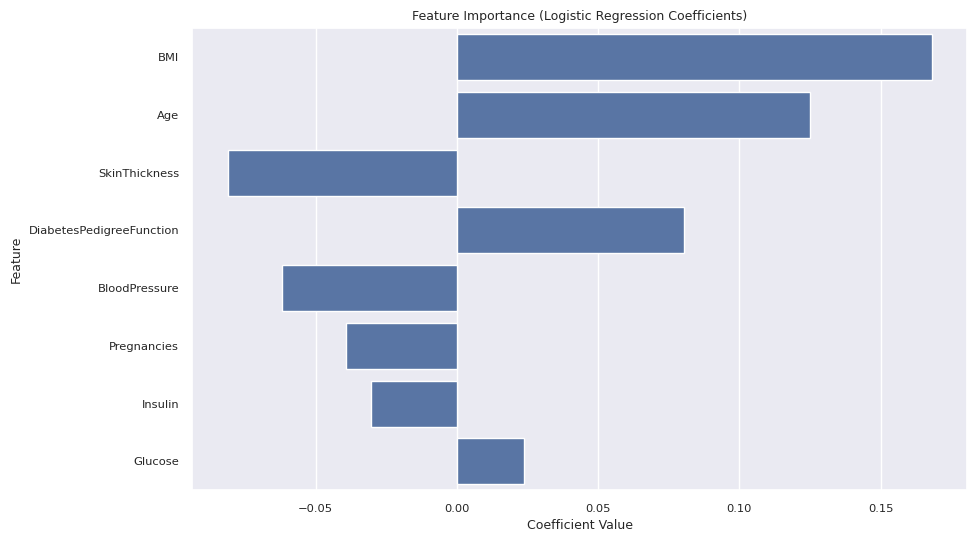

In [35]:
# 16. Coefficients for each feature
feature_importance = pd.DataFrame({'feature': X.columns, 'coefficient': model.coef_[0]})
feature_importance['abs_coefficient'] = abs(feature_importance['coefficient'])
feature_importance = feature_importance.sort_values(by='abs_coefficient', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='coefficient', y='feature', data=feature_importance)
plt.title('Feature Importance (Logistic Regression Coefficients)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.show()

AUC Score: 0.4541


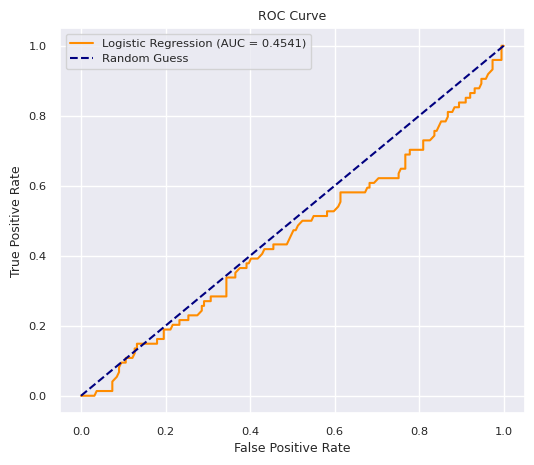

In [36]:
# 17 Plorint area under curve
#Predict probabilities for the positive class
y_probs = model.predict_proba(X_test)[:, 1]

    # Calculate AUC
from sklearn.metrics import roc_auc_score, roc_curve
auc_score = roc_auc_score(y_test, y_probs)
print(f"AUC Score: {auc_score:.4f}")

# Optional: Plot ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc_score:.4f})', color='darkorange',  )
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess', color='navy')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
len(y_test)





-------------------------
# This part is for demo test

---



In [39]:
from sklearn.datasets import load_diabetes
diabetes = load_diabetes()
diabetes.target[:3]
diabetes.data.shape

(442, 10)

In [42]:
diabetes.data[:3]

array([[ 0.03807591,  0.05068012,  0.06169621,  0.02187239, -0.0442235 ,
        -0.03482076, -0.04340085, -0.00259226,  0.01990749, -0.01764613],
       [-0.00188202, -0.04464164, -0.05147406, -0.02632753, -0.00844872,
        -0.01916334,  0.07441156, -0.03949338, -0.06833155, -0.09220405],
       [ 0.08529891,  0.05068012,  0.04445121, -0.00567042, -0.04559945,
        -0.03419447, -0.03235593, -0.00259226,  0.00286131, -0.02593034]])

# Linear Regression

Mean squared error: 2548.07
Coefficient of determination: 0.47


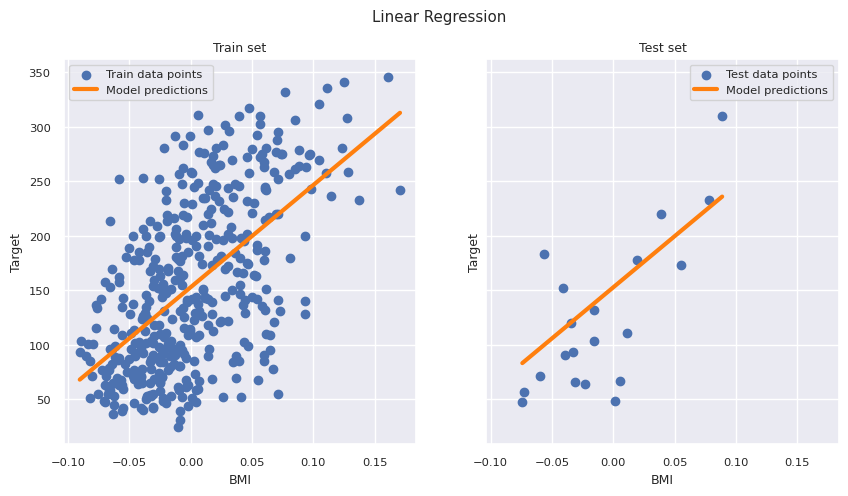

In [46]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split


X, y = load_diabetes(return_X_y=True)
X = X[:, [2]]  # Use only one feature, which is 'bmi' at index 2

'''X = diab_data_cleaned.drop('glyhb', axis=1)
y = diab_data_cleaned['glyhb']'''

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=20, shuffle=False)

from sklearn.linear_model import LinearRegression

regressor = LinearRegression().fit(X_train, y_train)

from sklearn.metrics import mean_squared_error, r2_score

y_pred = regressor.predict(X_test)

print(f"Mean squared error: {mean_squared_error(y_test, y_pred):.2f}")
print(f"Coefficient of determination: {r2_score(y_test, y_pred):.2f}")

import matplotlib.pyplot as plt
import pandas as pd

fig, ax = plt.subplots(ncols=2, figsize=(10, 5), sharex=True, sharey=True)

# Choose a single feature for plotting, which is 'BMI' from load_diabetes (index 2)
feature_name_to_plot = 'BMI'

# Training data plot
# Access the single column of the NumPy array using [:, 0]
ax[0].scatter(X_train[:, 0], y_train, label="Train data points")

# To plot a smooth regression line, sort the feature values and their corresponding predictions
train_data_for_plot = pd.DataFrame({
    feature_name_to_plot: X_train[:, 0],
    'prediction': regressor.predict(X_train)
}).sort_values(by=feature_name_to_plot)

ax[0].plot(
    train_data_for_plot[feature_name_to_plot],
    train_data_for_plot['prediction'],
    linewidth=3,
    color="tab:orange",
    label="Model predictions",
)
ax[0].set(xlabel=feature_name_to_plot, ylabel="Target", title="Train set")
ax[0].legend()

# Test data plot
# Access the single column of the NumPy array using [:, 0]
ax[1].scatter(X_test[:, 0], y_test, label="Test data points")

# To plot a smooth regression line for test data
test_data_for_plot = pd.DataFrame({
    feature_name_to_plot: X_test[:, 0],
    'prediction': y_pred
}).sort_values(by=feature_name_to_plot)

ax[1].plot(
    test_data_for_plot[feature_name_to_plot],
    test_data_for_plot['prediction'],
    linewidth=3,
    color="tab:orange",
    label="Model predictions",
)
ax[1].set(xlabel=feature_name_to_plot, ylabel="Target", title="Test set")
ax[1].legend()

fig.suptitle("Linear Regression")

plt.show()